# Backtester Core Engine

**Owner:** James  
**Version:** 2.0 (Feb 13, 2026)  

Core backtesting engine for evaluating sports betting strategies.  
All logic is imported from `src/cuic_quant/backtest/backtester_backend.py`.  
See `docs/reference/strategy-interface.md` for the strategy function contract.

## Output Format

| Column | Type | Description |
|--------|------|-------------|
| timestamp | datetime | When trade happened |
| game | str | "Home vs Away" |
| action | str | 'BUY_HOME' or 'BUY_AWAY' |
| bet_size | float | Dollars bet |
| odds | float | Decimal odds used |
| outcome | str | 'WIN' or 'LOSS' |
| pnl | float | Profit/loss for this trade |
| cumulative_pnl | float | Running total P&L |
| bankroll | float | Current bankroll after trade |

## Assumptions & Limitations

- **Odds at face value** -- no slippage, liquidity constraints, or market impact modeling. Bets are assumed to be filled at the quoted odds.
- **Synthetic data** -- the default dataset (`dummy_backtest_input.csv`) is generated test data, not real market data.
- **Single bet per game** -- no parlays, accumulators, or multi-leg bets.
- **No CLV (Closing Line Value)** -- our data has a single odds snapshot per game. CLV calculation requires closing odds data (future enhancement).
- **Transaction costs optional** -- costs default to 0. Use `cost_pct` and `cost_flat` parameters in `backtest()` to model bookmaker vig and fees.
- **Kelly sizing optional** -- use `position_sizing="kelly"` to enable Kelly Criterion bet sizing based on strategy confidence values.

In [1]:
import sys
from pathlib import Path

# Ensure src/ is importable when running from tools/ directory
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cuic_quant.backtest import (
    load_backtest_data,
    backtest,
    always_bet_home,
    kelly_bet_home,
    validate_backtest_results,
    display_extended_metrics,
    plot_performance,
)

## Configuration

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
DUMMY_CSV = DATA_DIR / "dummy_backtest_input.csv"

## Load Data

In [3]:
data = load_backtest_data("2026-01-01", "2026-01-31", csv_path=DUMMY_CSV)
print(f"Games loaded: {len(data)}")
data.head()

Loaded 25 rows from dummy_backtest_input.csv.
Games loaded: 25


,timestamp,game,home_team,away_team,home_odds,away_odds,home_win
0,2026-01-01,Lakers vs Celtics,Lakers,Celtics,1.95,2.05,1
1,2026-01-02,Warriors vs Heat,Warriors,Heat,1.80,2.20,1
2,2026-01-03,Bucks vs Nets,Bucks,Nets,1.65,2.45,1
3,2026-01-04,Nuggets vs Suns,Nuggets,Suns,2.10,1.85,0
4,2026-01-05,76ers vs Knicks,76ers,Knicks,1.90,2.00,1


## Strategy

Using the built-in `kelly_bet_home` strategy with **Kelly Criterion position sizing**. This strategy estimates win probability from implied odds (+ 5% edge) and Kelly sizes each bet as a fraction of the current bankroll.

To use your own strategy, replace the assignment below:

```python
def my_strategy(row, context=None):
    return {"action": "BUY_HOME", "confidence": 0.8, "size": 50.0}

strategy = my_strategy
```

For flat-bet sizing (ignoring confidence), omit `position_sizing` from the `backtest()` call.

See `docs/reference/strategy-interface.md` for the full contract.

In [4]:
strategy = kelly_bet_home

## Run Backtest

In [ ]:
results = backtest(data, strategy, initial_bankroll=10000.0, position_sizing="kelly", kelly_fraction=0.5)
print(f"Total trades: {len(results)}")
results

## Summary Statistics

In [6]:
if len(results) > 0:
    wins = (results["outcome"] == "WIN").sum()
    losses = (results["outcome"] == "LOSS").sum()
    win_rate = wins / len(results)
    final_pnl = results["cumulative_pnl"].iloc[-1]
    final_bankroll = results["bankroll"].iloc[-1]

    print(f"Win Rate:        {win_rate:.1%} ({wins}W / {losses}L)")
    print(f"Total P&L:       ${final_pnl:,.2f}")
    print(f"Final Bankroll:  ${final_bankroll:,.2f}")
    print(f"ROI:             {final_pnl / 10000:.1%}")
else:
    print("No trades executed.")

Win Rate:        60.0% (15W / 10L)
Total P&L:       $305.00
Final Bankroll:  $10,305.00
ROI:             3.0%


## Validate Results

Run the full validation suite to check schema, math correctness, and data leakage.

The validator runs **11 checks** across three categories:

### 1. Schema Validation (5 checks)
- **Column names** — output has exactly the 9 required columns in the correct order.
- **Valid actions** — every action is `BUY_HOME` or `BUY_AWAY` (no `SKIP` rows in output).
- **Valid outcomes** — every outcome is `WIN` or `LOSS`.
- **Positive bet sizes** — no zero or negative bets.
- **Valid odds** — all decimal odds are > 1.0.

### 2. Math Correctness (4 checks)
- **PnL formula** — WIN trades pay `bet_size * (odds - 1)`, LOSS trades pay `-bet_size`.
- **Cumulative PnL** — the `cumulative_pnl` column is a correct running sum of `pnl`.
- **Bankroll tracking** — `bankroll = initial_bankroll + cumulative_pnl` at every row.
- **No overbetting** — no bet exceeds the bankroll available at the time of the bet.

### 3. Data Leakage Detection (2 checks)
- **Outcome consistency** — each trade's outcome is cross-referenced against the original input data's `home_win` column. If a strategy somehow produced outcomes that don't match the actual game results, this catches it (e.g., a bug that lets the strategy "see" the outcome before betting).
- **Chronological order** — trades must be in timestamp order. Out-of-order trades could indicate the strategy accessed future game data to make decisions.

> **Why leakage checks matter:** A backtester bug that leaks future information (e.g., passing `home_win` to the strategy) would produce unrealistically high win rates. These checks verify the backtester correctly strips outcome data before calling the strategy.

In [7]:
report = validate_backtest_results(results, data)

if report["passed"]:
    print(f"PASSED: {report['checks_passed']}/{report['checks_run']} checks passed")
else:
    print(f"FAILED: {report['checks_passed']}/{report['checks_run']} checks passed")
    for f in report["failures"]:
        print(f"  - {f}")

PASSED: 12/12 checks passed


## Performance Metrics

Extended metrics from Ben's `cuic_quant.metrics` module plus additional risk/reward statistics.

In [8]:
display_extended_metrics(results)

       EXTENDED PERFORMANCE METRICS
  Sharpe Ratio:              2.057
  Sortino Ratio:             0.000
  Max Drawdown:              2.2%
  Profit Factor:             1.305
  Average Win:          $    87.00
  Average Loss:         $  -100.00
  Win/Loss Ratio:            0.870
  Expected Value/Bet:   $    12.20
  Longest Win Streak:            3
  Longest Loss Streak:           2
  Best Trade:           $   115.00
  Worst Trade:          $  -100.00


## Performance Graphs

Cumulative P&L, drawdown, P&L distribution, and trade outcomes.

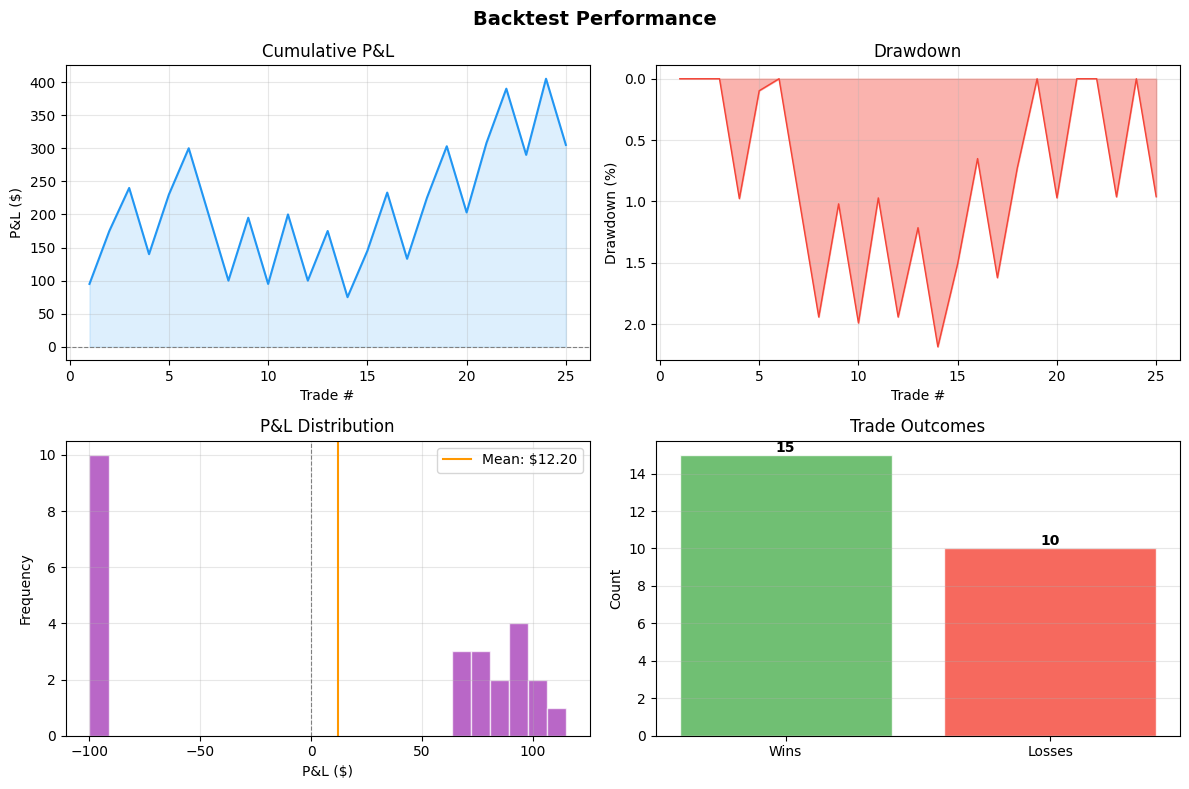

In [9]:
plot_performance(results)

## Conclusion

This notebook demonstrates the full backtesting pipeline:

1. **Data loading** from CSV (or Railway database when available)
2. **Strategy evaluation** using a pluggable strategy interface
3. **Validation** across 11 checks (schema, math, data leakage)
4. **Performance metrics** (Sharpe, Sortino, drawdown, profit factor, streaks)
5. **Visualizations** (equity curve, drawdown, PnL distribution, outcomes)

To build your own strategy, implement a function matching the interface in `docs/reference/strategy-interface.md` and pass it to `backtest()`.

For Kelly Criterion position sizing, set `position_sizing="kelly"` and return a `confidence` value (0-1) from your strategy.

For transaction cost modeling, use `cost_pct` (percentage on wins) and `cost_flat` (flat fee per trade).